# Baseline 3: VGG16 + Prototypical Network (Few-Shot Learning)

This notebook implements **Baseline 3**, using a **VGG16 backbone** with a **Prototypical Network head**.

Few-shot settings evaluated:
- 1-shot
- 5-shot
- 10-shot

Only the **final convolutional features** of VGG16 are used (single-scale).

## 1. Imports

In [10]:
import os, random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torchvision.models import VGG16_Weights

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## 2. Image Transform (VGG16 input size = 224×224)

In [11]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 3. Few-Shot Dataset Loader (Episodic Sampling)

This sampler creates N-way, K-shot episodes with Q query images per class.

In [12]:
class FewShotDataset:
    def __init__(self, root_dir, transform):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_images = {
            cls: os.listdir(os.path.join(root_dir, cls))
            for cls in self.classes
        }

    def sample_episode(self, n_way, k_shot, q_query):
        support_images, support_labels = [], []
        query_images, query_labels = [], []

        selected_classes = random.sample(self.classes, n_way)

        for label, cls in enumerate(selected_classes):
            # Handle insufficient images by reusing available ones
            images = self.class_to_images[cls]
            if len(images) < k_shot + q_query:
                # print(f"⚠️ Not enough images in class '{cls}'. Reusing available images.")
                images = (images * ((k_shot + q_query) // len(images) + 1))[:k_shot + q_query]

            sampled_images = random.sample(images, k_shot + q_query)
            cls_path = os.path.join(self.root_dir, cls)

            # Support samples
            for img_name in sampled_images[:k_shot]:
                img = Image.open(os.path.join(cls_path, img_name)).convert("RGB")
                support_images.append(self.transform(img))
                support_labels.append(label)

            # Query samples
            for img_name in sampled_images[k_shot:]:
                img = Image.open(os.path.join(cls_path, img_name)).convert("RGB")
                query_images.append(self.transform(img))
                query_labels.append(label)

        return (
            torch.stack(support_images),
            torch.tensor(support_labels),
            torch.stack(query_images),
            torch.tensor(query_labels)
        )

## 4. VGG16 Encoder

We remove the classifier head of VGG16 and apply **Global Average Pooling** on the final convolutional feature map.

**Output embedding dimension:** 512

In [13]:
class VGG16Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=VGG16_Weights.DEFAULT)

        # Use only convolutional feature extractor
        self.features = vgg.features

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = self.features(x)     # (B, 512, 7, 7)
        x = self.gap(x)          # (B, 512, 1, 1)
        x = x.view(x.size(0), -1)  # (B, 512)
        return x

## 5. Prototypical Network Head

Class prototypes are computed as the **mean embedding of support images**.
Euclidean distance is used for classification.

In [14]:
class ProtoNet(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder

    def forward(self, support_x, support_y, query_x):
        support_emb = self.encoder(support_x)
        query_emb = self.encoder(query_x)

        prototypes = []
        for c in torch.unique(support_y):
            prototypes.append(support_emb[support_y == c].mean(dim=0))
        prototypes = torch.stack(prototypes)

        distances = torch.cdist(query_emb, prototypes)
        return -distances

## 6. Training and Evaluation Function

A separate model is trained for each K-shot setting.

In [15]:
def train_and_evaluate(k_shot, episodes_train=100, episodes_eval=50):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_data = FewShotDataset("clean_dataset/train", transform)
    val_data = FewShotDataset("clean_dataset/val", transform)

    model = ProtoNet(VGG16Encoder()).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # -------- Training --------
    model.train()
    for episode in range(episodes_train):
        print(f"Training episode {episode + 1}/{episodes_train}...")
        sx, sy, qx, qy = train_data.sample_episode(
            n_way=4, k_shot=k_shot, q_query=10
        )

        sx, sy = sx.to(device), sy.to(device)
        qx, qy = qx.to(device), qy.to(device)

        scores = model(sx, sy, qx)
        loss = F.cross_entropy(scores, qy)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # -------- Evaluation --------
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for eval_episode in range(episodes_eval):
            print(f"Evaluating episode {eval_episode + 1}/{episodes_eval}...")
            sx, sy, qx, qy = val_data.sample_episode(
                n_way=4, k_shot=k_shot, q_query=10
            )

            sx, sy = sx.to(device), sy.to(device)
            qx, qy = qx.to(device), qy.to(device)

            preds = model(sx, sy, qx).argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(qy.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    return acc, cm

## 📊 Enhanced Evaluation with Comprehensive Metrics
**BASELINE 3 — VGG16 + Prototypical Networks**

Evaluates across 1-shot, 5-shot, and 10-shot settings and reports:
- Accuracy, Precision, Recall, F1-score (macro)
- Confusion Matrix per shot setting
- Stability (accuracy std-dev across episodes)

In [16]:
def train_and_evaluate_with_metrics(n_support_list, n_way, n_query, n_train_episodes, n_eval_episodes, learning_rate):
    # ── Device ──────────────────────────────────────────────────────
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    print(f"Using device: {device}")
    torch.set_num_threads(os.cpu_count())

    # ── Transform ───────────────────────────────────────────────────
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    # ── Datasets ────────────────────────────────────────────────────
    train_dataset = FewShotDataset("clean_dataset/train", transform)
    test_dataset  = FewShotDataset("clean_dataset/test",  transform)

    results = []

    for n_support in n_support_list:
        print(f"\n{'='*60}")
        print(f"  Training {n_support}-shot ({n_train_episodes} episodes) …")
        print(f"{'='*60}")

        # ── Fresh encoder + ProtoNet per shot setting ────────────────
        encoder = VGG16Encoder().to(device)
        model   = ProtoNet(encoder).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        # ── Training ────────────────────────────────────────────────
        model.train()
        for ep in range(1, n_train_episodes + 1):
            sx, sy, qx, qy = train_dataset.sample_episode(
                n_way=n_way, k_shot=n_support, q_query=n_query)
            sx, sy = sx.to(device), sy.to(device)
            qx, qy = qx.to(device), qy.to(device)

            logits = model(sx, sy, qx)
            loss   = F.cross_entropy(logits, qy)
            optimizer.zero_grad(); loss.backward(); optimizer.step()

            if ep % 20 == 0:
                print(f"  Episode {ep:>3}/{n_train_episodes}  loss={loss.item():.4f}")

        # ── Evaluation ──────────────────────────────────────────────
        model.eval()
        all_preds, all_labels, ep_accs = [], [], []

        with torch.no_grad():
            for ep in range(1, n_eval_episodes + 1):
                sx, sy, qx, qy = test_dataset.sample_episode(
                    n_way=n_way, k_shot=n_support, q_query=n_query)
                sx, sy = sx.to(device), sy.to(device)
                qx, qy = qx.to(device), qy.to(device)

                logits = model(sx, sy, qx)
                preds  = logits.argmax(dim=1)

                all_preds .extend(preds.cpu().numpy())
                all_labels.extend(qy.cpu().numpy())
                ep_accs.append(accuracy_score(qy.cpu().numpy(), preds.cpu().numpy()))

        acc  = accuracy_score (all_labels, all_preds)
        prec = precision_score(all_labels, all_preds, average="macro", zero_division=0)
        rec  = recall_score   (all_labels, all_preds, average="macro", zero_division=0)
        f1   = f1_score       (all_labels, all_preds, average="macro", zero_division=0)
        cm   = confusion_matrix(all_labels, all_preds)
        stab = np.std(ep_accs)

        results.append({
            "Shot":      f"{n_support}-shot",
            "Accuracy":  acc,
            "Precision": prec,
            "Recall":    rec,
            "F1-Score":  f1,
            "Stability": stab,
            "CM":        cm,
            "EpAccs":    ep_accs,
        })
        print(f"\n  [{n_support}-shot] Acc={acc:.4f}  P={prec:.4f}  R={rec:.4f}  F1={f1:.4f}  Stab±{stab:.4f}")

    return results

### ▶️ Run Comprehensive Evaluation

In [17]:
# Collects results from all 3 shot settings — run each cell below separately
results = []

In [18]:
# ── 1-SHOT ──────────────────────────────────────────────────────────────────
results += train_and_evaluate_with_metrics(
    n_support_list   = [1],
    n_way            = 4,
    n_query          = 15,
    n_train_episodes = 2000,
    n_eval_episodes  = 1000,
    learning_rate    = 0.001
)
print(f"✅ Done: {[r['Shot'] for r in results]}")

Using device: mps

  Training 1-shot (2000 episodes) …
  Episode  20/2000  loss=2.3311
  Episode  40/2000  loss=0.7743
  Episode  60/2000  loss=0.8285
  Episode  80/2000  loss=1.0830
  Episode 100/2000  loss=1.1792
  Episode 120/2000  loss=0.7751
  Episode 140/2000  loss=0.9642
  Episode 160/2000  loss=1.1072
  Episode 180/2000  loss=0.9451
  Episode 200/2000  loss=0.7927
  Episode 220/2000  loss=0.5993
  Episode 240/2000  loss=0.9382
  Episode 260/2000  loss=0.7438
  Episode 280/2000  loss=0.9484
  Episode 300/2000  loss=0.6975
  Episode 320/2000  loss=1.0221
  Episode 340/2000  loss=0.8164
  Episode 360/2000  loss=0.8667
  Episode 380/2000  loss=1.0033
  Episode 400/2000  loss=1.2930
  Episode 420/2000  loss=1.0598
  Episode 440/2000  loss=0.8669
  Episode 460/2000  loss=1.1655
  Episode 480/2000  loss=1.1394
  Episode 500/2000  loss=0.7692
  Episode 520/2000  loss=1.9899
  Episode 540/2000  loss=0.8256
  Episode 560/2000  loss=0.7215
  Episode 580/2000  loss=0.6007
  Episode 600/200

In [24]:
# ── 5-SHOT ──────────────────────────────────────────────────────────────────
results += train_and_evaluate_with_metrics(
    n_support_list   = [5],
    n_way            = 4,
    n_query          = 15,
    n_train_episodes = 2000,
    n_eval_episodes  = 1000,
    learning_rate    = 0.001    
)
print(f"✅ Done: {[r['Shot'] for r in results]}")

Using device: mps

  Training 5-shot (2000 episodes) …
  Episode  20/2000  loss=1.1024
  Episode  40/2000  loss=0.8995
  Episode  60/2000  loss=0.3847
  Episode  80/2000  loss=0.2888
  Episode 100/2000  loss=0.2526
  Episode 120/2000  loss=0.3150
  Episode 140/2000  loss=0.0571
  Episode 160/2000  loss=0.1266
  Episode 180/2000  loss=0.0179
  Episode 200/2000  loss=0.0199
  Episode 220/2000  loss=0.1860
  Episode 240/2000  loss=0.1730
  Episode 260/2000  loss=0.0478
  Episode 280/2000  loss=0.0498
  Episode 300/2000  loss=0.0086
  Episode 320/2000  loss=0.0014
  Episode 340/2000  loss=0.0002
  Episode 360/2000  loss=0.0966
  Episode 380/2000  loss=0.0170
  Episode 400/2000  loss=0.0846
  Episode 420/2000  loss=0.0788
  Episode 440/2000  loss=0.0003
  Episode 460/2000  loss=0.0241
  Episode 480/2000  loss=0.0015
  Episode 500/2000  loss=0.0012
  Episode 520/2000  loss=0.0001
  Episode 540/2000  loss=0.0004
  Episode 560/2000  loss=0.0109
  Episode 580/2000  loss=0.5038
  Episode 600/200

In [25]:
# ── 10-SHOT ─────────────────────────────────────────────────────────────────
results += train_and_evaluate_with_metrics(
    n_support_list   = [10],
    n_way            = 4,
    n_query          = 15,
    n_train_episodes = 2000,
    n_eval_episodes  = 1000,
    learning_rate    = 0.001
)
print(f"✅ Done: {[r['Shot'] for r in results]}")

Using device: mps

  Training 10-shot (2000 episodes) …
  Episode  20/2000  loss=0.5172
  Episode  40/2000  loss=0.3341
  Episode  60/2000  loss=2.0489
  Episode  80/2000  loss=0.1147
  Episode 100/2000  loss=0.2762
  Episode 120/2000  loss=0.1312
  Episode 140/2000  loss=0.6180
  Episode 160/2000  loss=0.0125
  Episode 180/2000  loss=0.0189
  Episode 200/2000  loss=0.1979
  Episode 220/2000  loss=0.1080
  Episode 240/2000  loss=0.0140
  Episode 260/2000  loss=0.1069
  Episode 280/2000  loss=0.0082
  Episode 300/2000  loss=0.0001
  Episode 320/2000  loss=0.0128
  Episode 340/2000  loss=0.0241
  Episode 360/2000  loss=0.0002
  Episode 380/2000  loss=0.0000
  Episode 400/2000  loss=0.0013
  Episode 420/2000  loss=0.0196
  Episode 440/2000  loss=0.4245
  Episode 460/2000  loss=0.6809
  Episode 480/2000  loss=0.2208
  Episode 500/2000  loss=0.0816
  Episode 520/2000  loss=0.0013
  Episode 540/2000  loss=0.9585
  Episode 560/2000  loss=0.0003
  Episode 580/2000  loss=0.1959
  Episode 600/20

### 📈 Results Summary Table

In [26]:
df = pd.DataFrame([
    {
        "Shot":       r["Shot"],
        "Accuracy":   f"{r['Accuracy']:.4f}",
        "Precision":  f"{r['Precision']:.4f}",
        "Recall":     f"{r['Recall']:.4f}",
        "F1-Score":   f"{r['F1-Score']:.4f}",
        "Stability (σ)": f"{r['Stability']:.4f}",
    }
    for r in results
])
df.set_index("Shot", inplace=True)
print("\n📊 Baseline 3 — VGG16 + ProtoNet Performance\n")
print(df.to_string())


📊 Baseline 3 — VGG16 + ProtoNet Performance

        Accuracy Precision  Recall F1-Score Stability (σ)
Shot                                                     
1-shot    0.8607    0.8608  0.8607   0.8606        0.0741
5-shot    0.7844    0.7844  0.7844   0.7844        0.0694
10-shot   0.8488    0.8488  0.8488   0.8488        0.0443


### 🎯 Confusion Matrices (1-shot / 5-shot / 10-shot)

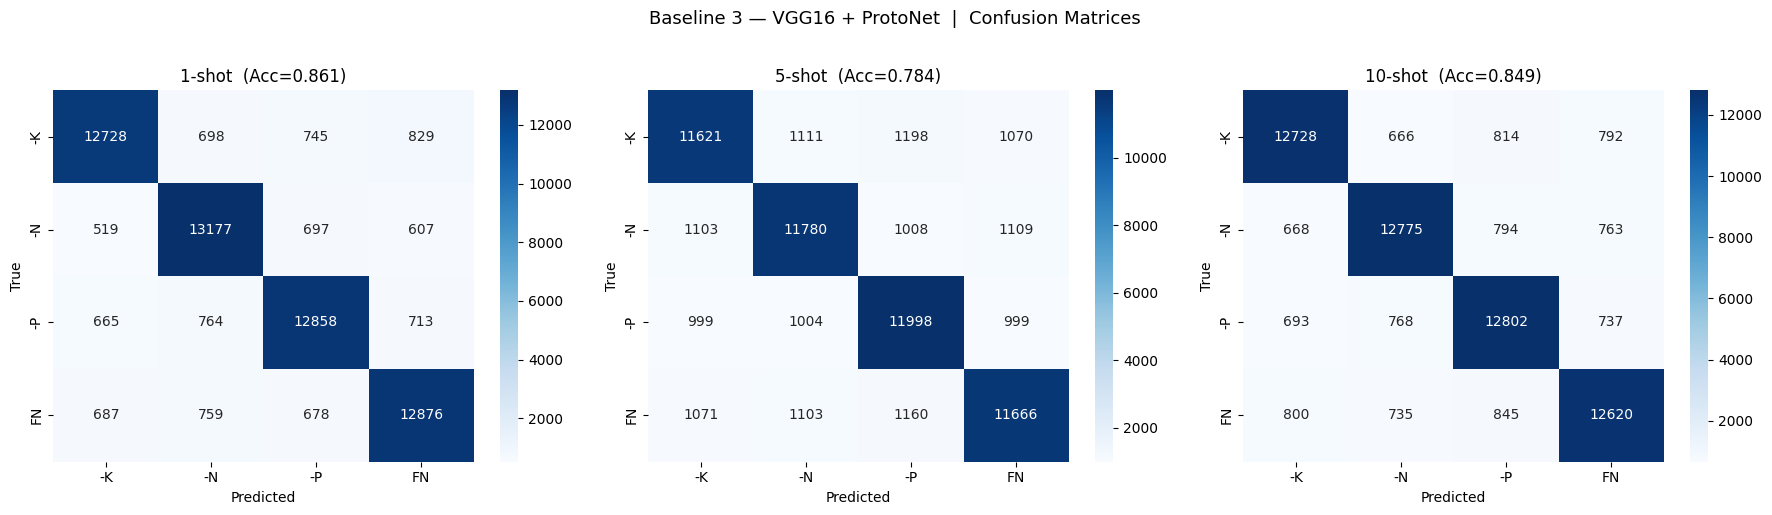

In [27]:
class_names = ["-K", "-N", "-P", "FN"]
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    sns.heatmap(
        r["CM"], annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=ax
    )
    ax.set_title(f"{r['Shot']}  (Acc={r['Accuracy']:.3f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Baseline 3 — VGG16 + ProtoNet  |  Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 📉 Stability Analysis Across Episodes

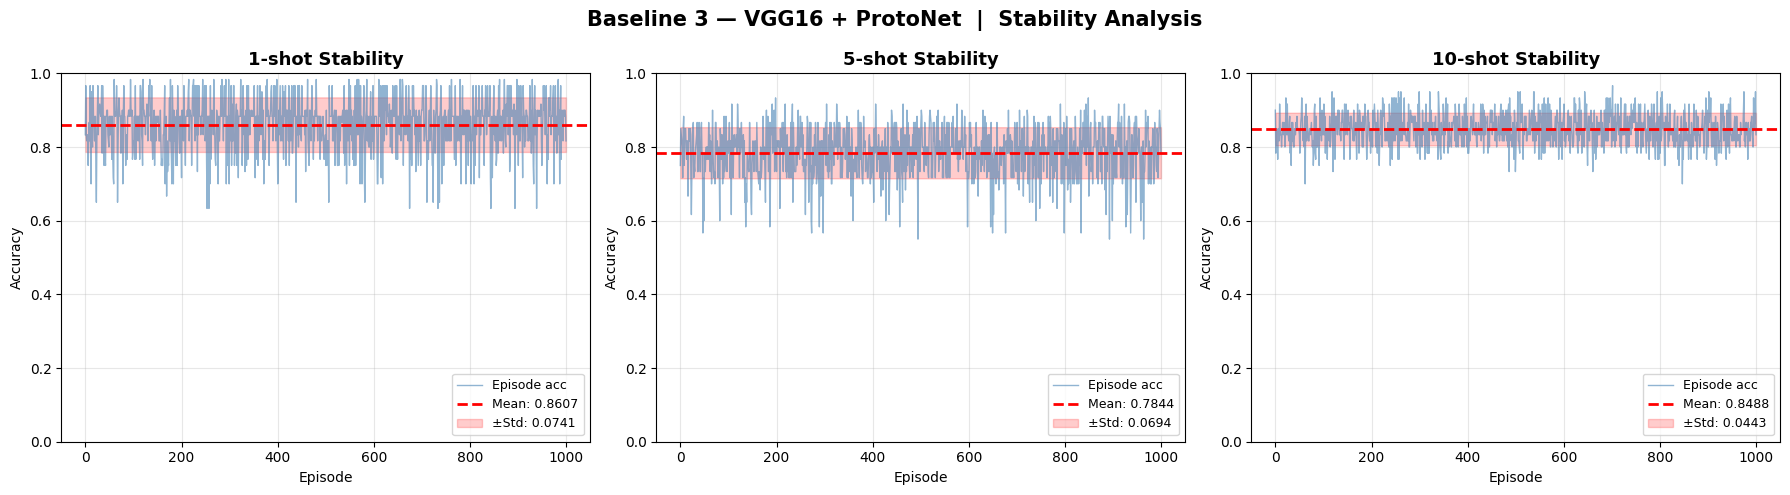

In [28]:

fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    ep_accs = r["EpAccs"]
    mean_acc = r["Accuracy"]
    std_acc  = r["Stability"]   

    ax.plot(ep_accs, alpha=0.6, linewidth=1, color='steelblue', label='Episode acc')
    ax.axhline(mean_acc, color='red', linestyle='--', linewidth=2,
               label=f"Mean: {mean_acc:.4f}")
    ax.fill_between(range(len(ep_accs)),
                    mean_acc - std_acc,
                    mean_acc + std_acc,
                    alpha=0.2, color='red', label=f"±Std: {std_acc:.4f}")
    ax.set_title(f"{r['Shot']} Stability", fontsize=13, fontweight='bold')
    ax.set_xlabel("Episode")
    ax.set_ylabel("Accuracy")
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

plt.suptitle("Baseline 3 — VGG16 + ProtoNet  |  Stability Analysis", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
